In [1]:
import pandas as pd
import numpy as np
import warnings
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
from scipy.stats import chi2_contingency
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.model_selection import  cross_val_predict
from sklearn.metrics import classification_report
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import FeatureUnion
from sklearn.impute import MissingIndicator
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import f1_score

warnings.filterwarnings('ignore')

In [2]:
#Models of interest
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, roc_auc_score


import torch 
import torch.nn as nn

In [3]:
df = pd.read_csv("Post_EDA_data.csv")
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,...,total_bc_limit,total_il_high_credit_limit,hardship_flag,debt_settlement_flag,y,Customer_history,loan_age_months,months_since_earliest_credit_line,current_balance_ratio,payment_progress_ratio
0,12000.0,12000.0,12000.0,36 months,7.97,375.88,A,A5,10+ years,OWN,...,15500.0,26180.0,N,N,1,7762,36,291,0.000000,1.000000
1,32000.0,32000.0,32000.0,36 months,11.99,1062.71,B,B5,10+ years,MORTGAGE,...,124200.0,20034.0,Y,N,1,4383,36,180,0.192465,0.807535
2,40000.0,40000.0,40000.0,60 months,15.05,952.65,C,C4,9 years,MORTGAGE,...,64600.0,168145.0,N,N,1,5632,36,221,0.559423,0.440577
3,16000.0,16000.0,16000.0,36 months,7.97,501.17,A,A5,5 years,RENT,...,3700.0,96918.0,N,N,1,6301,36,243,0.153464,0.846536
4,33000.0,33000.0,33000.0,36 months,7.21,1022.12,A,A3,< 1 year,MORTGAGE,...,81700.0,73015.0,Y,N,0,4292,36,177,0.299184,0.700816


In [4]:
df.shape

(2029952, 99)

In [5]:
#self.Q1_ saves the learned threshold from training so it can be consistently applied to new data.
class OutlierFlaggerv2(BaseEstimator, TransformerMixin):
    #Sklearn pipeline uses both x and y so thus we add y=None
    def fit(self,X, y=None):
        #To keep track of the columns
        X = pd.DataFrame(X)
        X.columns = X.columns.astype(str)
        self.feature_names_in_ = list(X.columns)
        self.Q1 = X.quantile(0.25)
        self.Q3 = X.quantile(0.75)
        self.IQR = self.Q3 - self.Q1
        #Return the capsulated info obtained
        return self

    def transform(self,X):
        X = pd.DataFrame(X, columns=self.feature_names_in_)
        X.columns = X.columns.astype(str)
        lower = self.Q1 -  1.5*self.IQR
        upper = self.Q3 +  1.5*self.IQR
        flags = ((X < lower) |(X>upper)).astype(int)
        #We keep the original feature and add a new column to capture outlier information, not replace it.

        flags.columns = [str(col) + "_outlier" for col in X.columns]
        
        return flags
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            #Store the input features in a variable, then to a list
            input_features = self.feature_names_in_
        input_features = [str(col) for col in input_features]
        outlier_names = [col + "_outlier" for col in input_features]
        return np.array(outlier_names, dtype=object)

## Cross Validation

In [6]:
#Divide from X and y
X = df.drop("y", axis=1)
y= df["y"]

In [7]:
#Dropped after seeing it was data leakage
X.drop(["recoveries","collection_recovery_fee"],axis=1, inplace=True)
#recoveries is the money recovered after a loan has defaulted.
#collection_recovery_fee is the cost charged for collecting that recovered money.


In [8]:
leakage_cols = [
    "out_prncp",
    "out_prncp_inv",
    "total_rec_prncp",
    "total_rec_late_fee",
    "last_pymnt_amnt",
    "debt_settlement_flag",
    "total_pymnt",
    "total_pymnt_inv",
    "total_rec_int"
]
X.drop(leakage_cols,axis=1,inplace=True)

In [9]:
#Hardship flag removal since it indicates if the borrower is haviung trouble paying
X.drop("hardship_flag",axis=1,inplace=True)

In [10]:
#subsample a subset of the data
X_sub = X.sample(n=200000, random_state=42)
y_sub = y.loc[X_sub.index]

In [11]:
# train/temp split
X_train, X_temp, y_train, y_temp = train_test_split(
    X_sub, y_sub,
    test_size=0.30,
    random_state=42,
    stratify=y_sub
)

#validation/test split
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

'''
Ideally we end up with
70% train
15% validation
15% test
'''

'\nIdeally we end up with\n70% train\n15% validation\n15% test\n'

In [12]:
numerical_columns = X.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns = X.select_dtypes(include=["object","category"]).columns

In [13]:
#Sample the numerical columns only from the training data
X_sample = X_train.sample(n=5000, random_state=42)
y_sample = y_train.loc[X_sample.index]

In [14]:
#Only numerical columns
X_num_sample = X_sample[numerical_columns]
X_num_sample.head()

,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,fico_range_low,fico_range_high,...,tax_liens,tot_hi_cred_lim,total_bal_ex_mort,total_bc_limit,total_il_high_credit_limit,Customer_history,loan_age_months,months_since_earliest_credit_line,current_balance_ratio,payment_progress_ratio
1308177,5000.0,5000.0,5000.0,17.57,179.69,20000.0,35.29,0.0,735.0,739.0,...,0.0,45599.0,36151.0,6500.0,32599.0,3103,66,168,0.000000,1.000000
690673,37600.0,37600.0,37600.0,7.21,1164.60,325000.0,12.62,1.0,770.0,774.0,...,0.0,540557.0,78845.0,184400.0,110052.0,7884,23,282,0.000000,1.000000
568761,9000.0,9000.0,9000.0,10.08,290.75,33000.0,27.71,0.0,675.0,679.0,...,0.0,36000.0,24728.0,31000.0,0.0,5844,26,218,0.453481,0.546519
1425531,28000.0,28000.0,27900.0,14.46,658.21,121400.0,5.07,0.0,755.0,759.0,...,0.0,926200.0,18207.0,30200.0,0.0,6453,54,266,0.000000,1.000000
1588854,28000.0,28000.0,28000.0,22.45,780.52,110000.0,14.87,5.0,665.0,669.0,...,0.0,517611.0,92630.0,4500.0,118470.0,6664,52,271,0.000000,0.378837


## PCA & t-nse

In [15]:
#Consruct the numerical pipeline and fit transform
#Try standard scaler and Robust
num_only_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median", add_indicator=True)),
    ("scaler", RobustScaler())
])

X_num_processed = num_only_pipe.fit_transform(X_num_sample)

In [16]:
#Do PCA on the trimmed data
pca = PCA(n_components=30, random_state=42)
X_pca = pca.fit_transform(X_num_processed)

In [17]:
#Apply t-nse
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_pca)

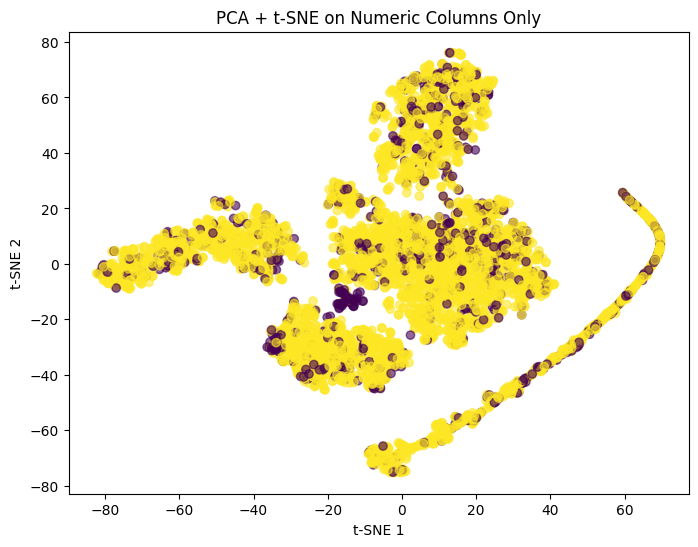

In [18]:
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y_sample, alpha=0.6)
plt.title("PCA + t-SNE on Numeric Columns Only")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

## ---------------------------

## Pipeline creation & post-transformation evaluation & Univariate variable selection

Block of code below assesses the multicollinearity between 2 numerical independent variables. If it is above a certain threshold we remove the one with less mutual information

In [19]:
#Version to fit into the pipeline
class CorrelationFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)

        corr_matrix = X.corr(numeric_only=True).abs()

        mask = np.triu(np.ones_like(corr_matrix), k=1).astype(bool)
        upper = corr_matrix.where(mask)

        #Use the set to not collect duplicates
        columns_to_drop = set()

        for col in upper.columns:
            for row in upper.index:
                if upper.loc[row,col] > self.threshold and pd.notna(upper.loc[row, col]):
                    #mutual info needs to be 2d inputted
                    mi_row = mutual_info_classif(X[[row]],y,random_state=45)
                    mi_col = mutual_info_classif(X[[col]],y,random_state=45)
                    #reminder larger values means stronger association
                    if mi_row[0] >= mi_col[0]:
                        columns_to_drop.add(col)
                    else:
                        columns_to_drop.add(row)
        self.columns_to_drop = list(columns_to_drop)
        self.feature_names = list(X.columns)

        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


In [20]:
def cramers_V(x,y):
    '''
    Here we calculate the Cramer's V to asses the strength of association between 2 nominal variables
    '''
    table =pd.crosstab(x,y)
    #Extract only the chi-square statistics
    chi2=chi2_contingency(table)[0]
    n = table.sum().sum()
    r,k = table.shape
    return np.sqrt(chi2 / (n*(min(r,k) -1)))

In [21]:
#Version to fit into the pipeline
class CategoricalFeatureSelector(BaseEstimator,TransformerMixin):
    def __init__(self, threshold=0.80):
        self.threshold = threshold

    def fit(self,X,y=None):
        X = pd.DataFrame(X)
        self.feature_names = list(X.columns)

        to_drop = set()

        for i in range(len(self.feature_names)):
            for j in range(i + 1, len(self.feature_names)):
                col1 = self.feature_names[i]
                col2 = self.feature_names[j]
                
                v = cramers_V(X[col1], X[col2])
                
                if v > self.threshold:
                    # compare usefulness with target using mutual info
                    x1_encoded = pd.factorize(X[col1])[0].reshape(-1, 1)
                    x2_encoded = pd.factorize(X[col2])[0].reshape(-1, 1)

                    mi1 = mutual_info_classif(x1_encoded, y, discrete_features=True, random_state=45)
                    mi2 = mutual_info_classif(x2_encoded, y, discrete_features=True, random_state=45)
                    
                    if mi1[0] >= mi2[0]:
                        to_drop.add(col2)
                    else:
                        to_drop.add(col1)
        self.columns_to_drop= list(to_drop)
        return self
    
    def transform(self,X):
        X = pd.DataFrame(X,columns=self.feature_names)
        return X.drop(columns=self.columns_to_drop,errors="ignore")
    
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names

        return np.array(
            [col for col in input_features if col not in self.columns_to_drop],
            dtype=object
        )


## Variable Selection via tree-based model

## Model selection

Here is the list of models, that are a candidate pool of models
* (FFN) Feed forward Nueral Network
* Logistic regression
* Xg Boost
* random forest

Maybe change from standard scaler to robust scaler

In [22]:
def model_summary(fitted_model, X_val,y_val,model_name):
    #Predicted probabilities for DV of 0
    y_probs = fitted_model.predict_proba(X_val)[:,0]
    y_pred = fitted_model.predict(X_val)

    class_report = classification_report(y_val,y_pred)
    # ROC values
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    # AUC
    auc = roc_auc_score(1-y_val, y_probs)

    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    #Baseline
    plt.plot([0, 1], [0, 1], linestyle='--') 
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve of DV=0")
    plt.legend()
    plt.show()


    print(class_report)
    print(f"current model auc:{auc:3f}")
    print(f"current model name:{model_name}")

In [23]:
numerical_columns_train = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_columns_train = X_train.select_dtypes(include=["object","category"]).columns

In [24]:
def Youden_threshold(fitted_model, X_val, y_val):
    
    # Probability of original class 0
    y_probs = fitted_model.predict_proba(X_val)[:, 0]

    # Treat original class 0 as the positive class
    fpr, tpr, thresholds = roc_curve(y_val, y_probs, pos_label=0)

    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    j_threshold = thresholds[best_idx]

    print(f"Youden threshold for class 0: {j_threshold}")
    
    # Predict class 0 if probability of class 0 is above threshold
    y_pred_changed = np.where(y_probs >= j_threshold, 0, 1)
   
    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_changed))

    return j_threshold

In [25]:
def f1_threshold(fitted_model, X_val, y_val):

    # Probability of class 0
    y_probs_0 = fitted_model.predict_proba(X_val)[:, 0]

    thresholds = np.linspace(0, 1, 100)
    f1_scores = []

    for t in thresholds:
        # Predict class 0 if probability of class 0 >= threshold
        y_pred = np.where(y_probs_0 >= t, 0, 1)

        # F1 score for class 0
        score = f1_score(y_val, y_pred, pos_label=0)
        f1_scores.append(score)

    best_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[best_idx]

    print(f"F1 optimal threshold for class 0: {optimal_threshold}")

    y_pred_optimal = np.where(y_probs_0 >= optimal_threshold, 0, 1)

    print("Classification report with threshold")
    print(classification_report(y_val, y_pred_optimal))

    return optimal_threshold

In [28]:
from sklearn.preprocessing import FunctionTransformer

to_dense = FunctionTransformer(
    lambda x: x.toarray() if hasattr(x, "toarray") else x
)

to_float = FunctionTransformer(
    lambda x: x.astype(np.float32)
)

In [30]:
models_of_interest =[
("Logistic Regression",LogisticRegression(max_iter=1000)),
("Random Forest",RandomForestClassifier(n_estimators=200,random_state=42)),
("XG Boost",XGBClassifier())
]

Research Goal: Can we predict whether a LendingClub loan is in good standing based on the borrower’s current financial and credit profile?

## Preprocessing & feature selection pipeline

In [31]:
numerical_train_columns = X_train.select_dtypes(include="number", exclude=["category","object"]).columns
Cat_train_columns = X_train.select_dtypes(include=["object","category"]).columns

In [32]:
#Pipeline that is built with the preprocessing, and feature selection

#Categorical pipeline
cat_pip = Pipeline([
    ("imputer",SimpleImputer(strategy='constant',fill_value="missing")),
    ("feature_selector",CategoricalFeatureSelector(threshold=0.80)),
    ("ohe", OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False))
])

#Numerical Pipeline
numerical_pip = FeatureUnion([
    ("scaled_num", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler())
    ])),

    ("outlier_flags", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("outlier_flag", OutlierFlaggerv2())
    ])),

    ("missing_flags", MissingIndicator(features="missing-only"))
])

#ColumnTransformer
preprocessing = ColumnTransformer(
    transformers=[
        ("cat", cat_pip, Cat_train_columns),
        ("num", numerical_pip, numerical_train_columns),
    ],
    remainder="passthrough"
)

In [33]:
baseline_pipeline = Pipeline([
    ("process",preprocessing),
    ("corr_selector", CorrelationFeatureSelector(threshold=0.80)),
    ("tree_selector",SelectFromModel(
        RandomForestClassifier(n_estimators=1000,random_state=42), threshold='mean'
    )),
    ("model", LogisticRegression(max_iter=1000))
])

In [34]:
baseline_pipeline.fit(X_train,y_train)

,steps,"[('process', ...), ('corr_selector', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


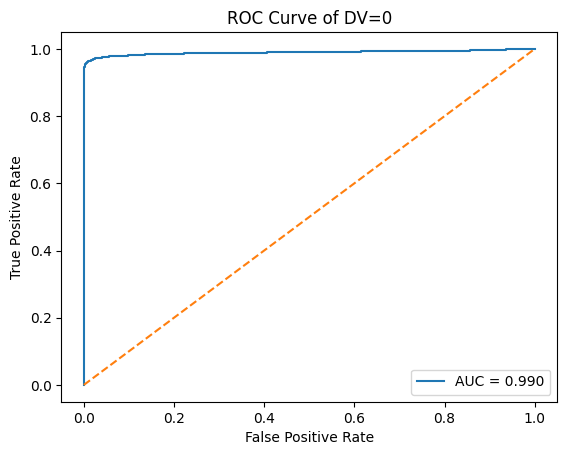

              precision    recall  f1-score   support

           0       0.99      0.94      0.97      4822
           1       0.99      1.00      0.99     25178

    accuracy                           0.99     30000
   macro avg       0.99      0.97      0.98     30000
weighted avg       0.99      0.99      0.99     30000

current model auc:0.989512
current model name:base


In [35]:
model_summary(baseline_pipeline, X_val, y_val, "base")

In [36]:
df["y"].value_counts()

y
1    1704881
0     325071
Name: count, dtype: int64

In [37]:
f1_threshold(baseline_pipeline,X_val,y_val)

F1 optimal threshold for class 0: 0.36363636363636365
Classification report with threshold
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4822
           1       0.99      1.00      0.99     25178

    accuracy                           0.99     30000
   macro avg       0.99      0.97      0.98     30000
weighted avg       0.99      0.99      0.99     30000



np.float64(0.36363636363636365)

In [38]:
Youden_threshold(baseline_pipeline,X_val,y_val)

Youden threshold for class 0: 0.24795649592288738
Classification report with threshold
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      4822
           1       0.99      0.99      0.99     25178

    accuracy                           0.99     30000
   macro avg       0.98      0.98      0.98     30000
weighted avg       0.99      0.99      0.99     30000



np.float64(0.24795649592288738)

In [39]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

param_dist = [
    {
        "model": [LogisticRegression(max_iter=1000)],
        "model__C": uniform(0.01, 10),
        "model__class_weight": [None, "balanced"]
    },
    {
        "model": [RandomForestClassifier(random_state=42)],
        "model__n_estimators": randint(100, 800),
        "model__max_depth": [5, 10, 20, None],
        "model__class_weight": [None, "balanced"]
    },
    {
        "model": [XGBClassifier(random_state=42, eval_metric="logloss")],
        "model__n_estimators": randint(100, 500),
        "model__max_depth": randint(2, 8),
        "model__learning_rate": uniform(0.01, 0.2)
    }
]

random_search = RandomizedSearchCV(
    estimator=baseline_pipeline,
    param_distributions=param_dist,
    n_iter=5,          # tries 20 random combinations total
    cv=5,
    scoring="f1_macro",
    n_jobs=-1,
    random_state=42
)

random_search.fit(X_train, y_train)

,estimator,Pipeline(step..._iter=1000))])
,param_distributions,"[{'model': [LogisticRegre...max_iter=1000)], 'model__C': <scipy.stats....001898C2D01A0>, 'model__class_weight': [None, 'balanced']}, {'model': [RandomForestC...ndom_state=42)], 'model__class_weight': [None, 'balanced'], 'model__max_depth': [5, 10, ...], 'model__n_estimators': <scipy.stats....00189B7EE1160>}, ...]"
,n_iter,5
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [40]:
print("Best CV score:")
print(random_search.best_score_)

print("\nBest parameters:")
print(random_search.best_params_)

print("\nBest full pipeline/model:")
print(random_search.best_estimator_)

Best CV score:
0.9904111703172814

Best parameters:
{'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...), 'model__learning_rate': np.float64(0.1693085973720466), 'model__max_depth': 4, 'model__n_estimators': 171}

Best full pipeline/model:
Pipeline(steps=[('proce

In [1]:
best_model = random_search.best_estimator_

NameError: name 'random_search' is not defined

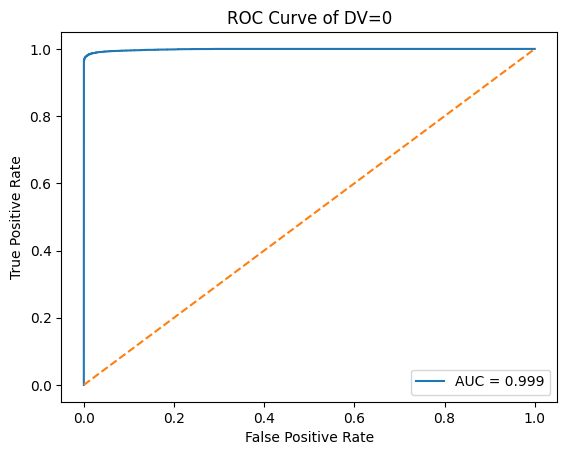

              precision    recall  f1-score   support

           0       0.99      0.97      0.98      4822
           1       0.99      1.00      1.00     25178

    accuracy                           0.99     30000
   macro avg       0.99      0.98      0.99     30000
weighted avg       0.99      0.99      0.99     30000

current model auc:0.998705
current model name:Best Random Search Model


In [42]:
model_summary(best_model, X_val, y_val, "Best Random Search Model")

In [43]:
import numpy as np
import pandas as pd

# ============================================================
# 1. Get best fitted pipeline pieces
# ============================================================

best_pipe = random_search.best_estimator_

process = best_pipe.named_steps["process"]
corr_selector = best_pipe.named_steps["corr_selector"]
tree_selector = best_pipe.named_steps["tree_selector"]
best_model = best_pipe.named_steps["model"]


# ============================================================
# 2. Get categorical feature names manually
# ============================================================

cat_pipeline = process.named_transformers_["cat"]
cat_selector = cat_pipeline.named_steps["feature_selector"]
ohe = cat_pipeline.named_steps["ohe"]

cat_cols = np.array(Cat_train_columns, dtype=object)

columns_to_drop = getattr(cat_selector, "columns_to_drop", [])

print("Categorical columns originally:")
print(cat_cols)

print("\nCategorical columns dropped by selector:")
print(columns_to_drop)

# If your selector stored dropped columns as integer positions
if len(columns_to_drop) > 0 and isinstance(columns_to_drop[0], (int, np.integer)):
    kept_cat_cols = np.delete(cat_cols, columns_to_drop)

# If your selector stored dropped columns as names
elif len(columns_to_drop) > 0 and isinstance(columns_to_drop[0], str):
    kept_cat_cols = np.array([
        col for col in cat_cols
        if col not in columns_to_drop
    ], dtype=object)

# If nothing was dropped
else:
    kept_cat_cols = cat_cols

print("\nCategorical columns kept:")
print(kept_cat_cols)

# Now this should match the number of columns OneHotEncoder saw
cat_feature_names = ohe.get_feature_names_out(kept_cat_cols)

print("\nNumber of OHE categorical features:")
print(len(cat_feature_names))

print("\nFirst 20 categorical feature names:")
print(cat_feature_names[:20])


# ============================================================
# 3. Get numeric feature names manually
# ============================================================

num_cols = np.array(numerical_train_columns, dtype=object)

scaled_num_names = np.array([
    f"scaled_num__{col}" for col in num_cols
], dtype=object)

outlier_flag_names = np.array([
    f"outlier_flags__{col}_outlier" for col in num_cols
], dtype=object)

# MissingIndicator is inside the FeatureUnion
num_pipeline = process.named_transformers_["num"]
missing_indicator = num_pipeline.transformer_list[2][1]

missing_cols = num_cols[missing_indicator.features_]

missing_flag_names = np.array([
    f"missing_flags__{col}_missing" for col in missing_cols
], dtype=object)


# ============================================================
# 4. Combine all feature names after preprocessing
# ============================================================

feature_names_after_process = np.concatenate([
    cat_feature_names,
    scaled_num_names,
    outlier_flag_names,
    missing_flag_names
])

X_processed = process.transform(X_train)

print("\nShape after preprocessing:")
print(X_processed.shape)

print("\nNumber of feature names created:")
print(len(feature_names_after_process))

assert X_processed.shape[1] == len(feature_names_after_process), \
    "Feature names do not match processed data shape."

print("\nFeature names match processed data shape.")


# ============================================================
# 5. Get features after CorrelationFeatureSelector
# ============================================================

corr_columns_to_drop = getattr(corr_selector, "columns_to_drop", [])

print("\nColumns dropped by correlation selector:")
print(corr_columns_to_drop)

if len(corr_columns_to_drop) > 0 and isinstance(corr_columns_to_drop[0], str):
    features_after_corr = np.array([
        feature for feature in feature_names_after_process
        if feature not in corr_columns_to_drop
    ], dtype=object)

elif len(corr_columns_to_drop) > 0 and isinstance(corr_columns_to_drop[0], (int, np.integer)):
    features_after_corr = np.delete(feature_names_after_process, corr_columns_to_drop)

else:
    features_after_corr = feature_names_after_process

print("\nNumber of features after correlation selector:")
print(len(features_after_corr))


# ============================================================
# 6. Get final features after tree selector
# ============================================================

tree_mask = tree_selector.get_support()

final_features = features_after_corr[tree_mask]

print("\nNumber of final features used by model:")
print(len(final_features))

final_features_df = pd.DataFrame({
    "final_feature": final_features
})

display(final_features_df)


# ============================================================
# 7. Feature importance / coefficients
# ============================================================

if hasattr(best_model, "coef_"):
    importance_df = pd.DataFrame({
        "feature": final_features,
        "coefficient": best_model.coef_[0]
    })

    importance_df["abs_importance"] = importance_df["coefficient"].abs()

    importance_df = importance_df.sort_values(
        "abs_importance",
        ascending=False
    )

elif hasattr(best_model, "feature_importances_"):
    importance_df = pd.DataFrame({
        "feature": final_features,
        "importance": best_model.feature_importances_
    })

    importance_df = importance_df.sort_values(
        "importance",
        ascending=False
    )

else:
    importance_df = pd.DataFrame({
        "feature": final_features
    })

print("\nTop final features:")
display(importance_df.head(30))

Categorical columns originally:
['term' 'grade' 'sub_grade' 'emp_length' 'home_ownership'
 'verification_status' 'purpose' 'addr_state']

Categorical columns dropped by selector:
[1]

Categorical columns kept:
['term' 'sub_grade' 'emp_length' 'home_ownership' 'verification_status'
 'purpose' 'addr_state']

Number of OHE categorical features:
112

First 20 categorical feature names:
['term_60 months' 'sub_grade_A2' 'sub_grade_A3' 'sub_grade_A4'
 'sub_grade_A5' 'sub_grade_B1' 'sub_grade_B2' 'sub_grade_B3'
 'sub_grade_B4' 'sub_grade_B5' 'sub_grade_C1' 'sub_grade_C2'
 'sub_grade_C3' 'sub_grade_C4' 'sub_grade_C5' 'sub_grade_D1'
 'sub_grade_D2' 'sub_grade_D3' 'sub_grade_D4' 'sub_grade_D5']

Shape after preprocessing:
(140000, 293)

Number of feature names created:
293

Feature names match processed data shape.

Columns dropped by correlation selector:
[257, 130, 259, 134, 263, 265, 271, 272, 273, 274, 275, 276, 278, 279, 280, 153, 281, 282, 283, 157, 284, 287, 289, 164, 292, 169, 170, 171, 1

,final_feature
0,term_60 months
1,scaled_num__int_rate
2,scaled_num__installment
3,scaled_num__annual_inc
4,scaled_num__dti
5,scaled_num__fico_range_high
6,scaled_num__mths_since_last_delinq
7,scaled_num__revol_bal
8,scaled_num__revol_util
9,scaled_num__total_acc



Top final features:


,feature,importance
10,scaled_num__last_fico_range_high,0.422116
31,outlier_flags__current_balance_ratio_outlier,0.305763
30,scaled_num__payment_progress_ratio,0.224773
0,term_60 months,0.004357
2,scaled_num__installment,0.002394
19,scaled_num__bc_open_to_buy,0.002167
8,scaled_num__revol_util,0.002013
5,scaled_num__fico_range_high,0.001925
26,scaled_num__num_bc_tl,0.001751
29,scaled_num__Customer_history,0.001657


## Slightly more complex model selection

In [44]:
from sklearn.metrics import make_scorer, f1_score

#to make a score that is f1, score but to detect it on the minority cl asss 0
f1_class_0 = make_scorer(f1_score, pos_label=0)

In [45]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

In [46]:
pipe = Pipeline(steps=[
    ('preprocess', preprocessing),
    ('sampler', 'passthrough'),
    ('model', LogisticRegression())
])

In [47]:
param_distributions = [
    #Each dictionary value is for each model set up, like for example each differnt versions of Logistic regression are based on the different model penalties, and not all can use other model penalties
    # Logistic Regression
    {
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [LogisticRegression(max_iter=5000)],
        'model__penalty': ['l2'],
        'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
        'model__solver': ['lbfgs', 'saga'],
        'model__class_weight': [None, 'balanced']
    },

    {
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [LogisticRegression(max_iter=5000)],
        'model__penalty': ['l1'],
        'model__C': [0.001, 0.01, 0.1, 1, 10],
        'model__solver': ['saga'],
        'model__class_weight': [None, 'balanced']
    },

    # Random Forest
    {
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [RandomForestClassifier(random_state=42)],
        'model__n_estimators': [100, 300, 500],
        'model__max_depth': [None, 10, 20, 30],
        'model__min_samples_split': [2, 5, 10],
        'model__min_samples_leaf': [1, 2, 5, 10],
        'model__max_features': ['sqrt', 'log2'],
        'model__class_weight': [None, 'balanced']
    },

    # XGBoost
    {
        'sampler': [
            'passthrough',
            SMOTE(random_state=42),
            RandomOverSampler(random_state=42),
            RandomUnderSampler(random_state=42)
        ],
        'model': [XGBClassifier(
            random_state=42,
            eval_metric='logloss'
        )],
        'model__n_estimators': [100, 300, 500,800],
        'model__learning_rate': [0.01, 0.05, 0.1],
        'model__max_depth': [3, 4, 5],
        'model__subsample': [0.6, 0.8, 1.0],
        'model__colsample_bytree': [0.6, 0.8, 1.0]
    }
]

In [48]:
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_distributions,
    n_iter=20,
    scoring=f1_class_0,
    cv=5,
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,estimator,Pipeline(step...egression())])
,param_distributions,"[{'model': [LogisticRegre...max_iter=5000)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l2'], ...}, {'model': [LogisticRegre...max_iter=5000)], 'model__C': [0.001, 0.01, ...], 'model__class_weight': [None, 'balanced'], 'model__penalty': ['l1'], ...}, ...]"
,n_iter,20
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [49]:
best_model = random_search.best_estimator_

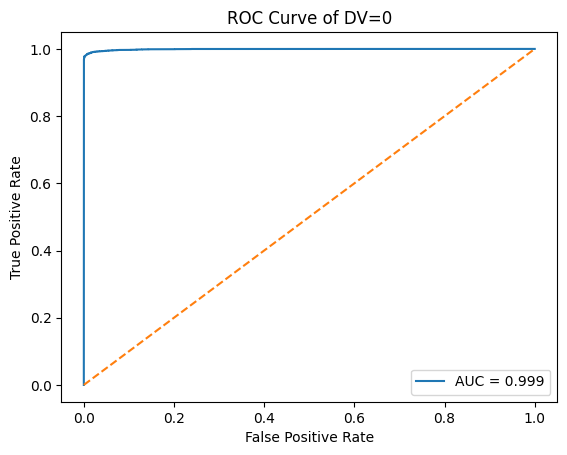

              precision    recall  f1-score   support

           0       1.00      0.97      0.98      4822
           1       0.99      1.00      1.00     25178

    accuracy                           0.99     30000
   macro avg       1.00      0.99      0.99     30000
weighted avg       0.99      0.99      0.99     30000

current model auc:0.999129
current model name:Best Random Search Model


In [50]:
model_summary(best_model, X_val, y_val, "Best Random Search Model")

In [51]:
print("\nBest parameters:")
print(random_search.best_params_)


Best parameters:
{'sampler': 'passthrough', 'model__subsample': 0.8, 'model__n_estimators': 500, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__colsample_bytree': 0.8, 'model': XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)}


In [52]:
from torch.optim import Adam
from skorch import NeuralNetClassifier

In [53]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [54]:
class MLPClassifier(nn.Module):
    def __init__(self,dropout=0.30):
        super().__init__()

        # LazyLinear automatically figures out input_dim on first batch
        self.input_to_hidden = nn.LazyLinear(16)
        
        self.hidden_to_hidden_1 = nn.Linear(16, 32)
        self.hidden_to_hidden_2 = nn.Linear(32, 64)
        self.hidden_to_hidden_3 = nn.Linear(64, 128)
        self.dropout = nn.Dropout(p=dropout)
        self.hidden_to_output = nn.Linear(128,2)


    def forward(self, X):
        hidden = torch.relu(self.input_to_hidden(X))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_1(hidden))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_2(hidden))
        hidden = self.dropout(hidden)

        hidden = torch.relu(self.hidden_to_hidden_3(hidden))
        hidden = self.dropout(hidden)

        logits = self.hidden_to_output(hidden)
        return logits

In [55]:
net = NeuralNetClassifier(
    module=MLPClassifier,
    module__dropout=0.3,

    criterion=nn.CrossEntropyLoss,

    optimizer=torch.optim.Adam,
    optimizer__lr=0.001,
    optimizer__weight_decay=0.01,

    max_epochs=500,
    batch_size=256,
    iterator_train__shuffle=True,
    device=device,
    verbose=1
)

In [56]:
from sklearn.preprocessing import FunctionTransformer

In [57]:
nn_pipe = Pipeline(steps=[
    ("preprocess", preprocessing),
    ("to_float32", FunctionTransformer(lambda X: X.astype(np.float32), validate=False)),
    ("model", net)
])

In [58]:
from scipy.stats import loguniform, uniform

param_dist = {
    "model__optimizer__lr": loguniform(1e-4, 1e-2),
    "model__optimizer__weight_decay": loguniform(1e-5, 1e-1),
    "model__module__dropout": uniform(0.1, 0.4)  # tries 0.1 to 0.5
}

random_search = RandomizedSearchCV(
    estimator=nn_pipe,
    param_distributions=param_dist,
    n_iter=10,
    scoring=f1_class_0,
    cv=3,
    random_state=42,
    verbose=2,
    n_jobs=-1
)

random_search.fit(X_train, y_train.astype("int64"))

Fitting 3 folds for each of 10 candidates, totalling 30 fits
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.5208       0.8393        0.3567  3.0389
      2        0.3112       0.8224        0.2290  2.9133
      3        0.2090       0.9703        0.1341  2.8382
      4        0.1526       0.9710        0.1072  2.8725
      5        0.1366       0.9806        0.0776  2.8751
      6        0.1257       0.9826        0.0658  3.0542
      7        0.0934       0.9843        0.0592  2.9177
      8        0.0854       0.9885        0.0496  2.8383
      9        0.0810       0.9831        0.0593  3.0376
     10        0.0834       0.9881        0.0454  2.8963
     11        0.0751       0.9887        0.0452  2.8179
     12        0.0773       0.9838        0.0529  2.8371
     13        0.0753       0.9875        0.0469  2.8671
     14        0.0732       0.9891        0.0430  2.7985
     15        0.0687      

,estimator,Pipeline(step...tart=False))])
,param_distributions,"{'model__module__dropout': <scipy.stats....0018A5C3F7100>, 'model__optimizer__lr': <scipy.stats....0018A5C40FED0>, 'model__optimizer__weight_decay': <scipy.stats....0018A5C3F6780>}"
,n_iter,10
,scoring,"make_scorer(f..., pos_label=0)"
,n_jobs,-1
,refit,True
,cv,3
,verbose,2
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [59]:
best_model = random_search.best_estimator_

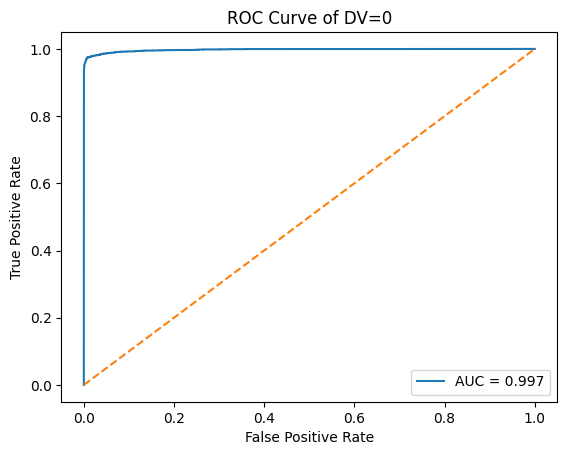

              precision    recall  f1-score   support

           0       0.99      0.95      0.97      4822
           1       0.99      1.00      0.99     25178

    accuracy                           0.99     30000
   macro avg       0.99      0.97      0.98     30000
weighted avg       0.99      0.99      0.99     30000

current model auc:0.997487
current model name:Best Random Search Model


In [60]:
model_summary(best_model, X_val, y_val, "Best Random Search Model")

“Given the borrower and loan information available now, can we classify whether the loan is currently in good standing or risky?”

## ------------------------